# Curve fitting a heat-capacity polynomial

**Skills: reading a data file, least-squares fitting, residual plots.** Work through
*Getting started with Python and Jupyter* first if you have not already.

The ideal-gas heat capacity of a substance is tabulated in **Appendix A.II** as a cubic in
temperature,

$$C_P^{*}(T) = a + b\,T + c\,T^{2} + d\,T^{3}\qquad[\mathrm{J/(mol\,K)}],\ T\ \text{in K}.$$

Those four numbers came from somewhere. Somebody took measured heat capacities and found
the cubic that passed closest to them — a **least-squares fit** — and this notebook repeats
that exercise for carbon dioxide, then compares the result with the book's own coefficients.

The reference data come from the NIST Chemistry WebBook, which reports $C_P^{*}$ through the
*Shomate* equation — a **different** functional form:

$$C_P^{*}(T) = A + B\,t + C\,t^{2} + D\,t^{3} + \frac{E}{t^{2}},\qquad t = T/1000.$$

So this is a genuine fit and not a copying exercise: we are approximating one model, which
has a $1/t^{2}$ term, by the book's simpler cubic, which does not.

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# Does nothing if you cloned the repository -- the data folder is already beside
# this notebook. In Colab there is no repository, so fetch the property data.
import os

DATA = "../data" if os.path.isdir("../data") else "data"
if not os.path.isdir(DATA):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/data .
    DATA = "data"
# ---------------------------------------------------------------------------
print("reading data from", DATA)

reading data from ../data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. The reference data

NIST gives the gas-phase Shomate parameters for CO$_2$ over 298–1200 K (Chase,
*NIST-JANAF Thermochemical Tables*, 1998). Evaluating them on a grid of temperatures gives
us the $(T, C_P)$ points that will play the part of "the data".

In [3]:
# CO2 gas phase, 298-1200 K (NIST WebBook, species C124389)
A_s, B_s, C_s, D_s, E_s = 24.99735, 55.18696, -33.69137, 7.948387, -0.136638


def cp_nist(T):
    """Reference ideal-gas Cp*, J/(mol K), from the NIST Shomate equation."""
    t = np.asarray(T) / 1000.0
    return A_s + B_s*t + C_s*t**2 + D_s*t**3 + E_s/t**2


T_data = np.arange(300.0, 1201.0, 50.0)      # K
Cp_data = cp_nist(T_data)                    # J/(mol K)

print(f"{'T (K)':>7}{'Cp (J/mol/K)':>15}")
for Ti, Cpi in zip(T_data, Cp_data):
    print(f"{Ti:7.0f}{Cpi:15.2f}")

  T (K)   Cp (J/mol/K)
    300          37.22
    350          39.41
    400          41.34
    450          43.06
    500          44.61
    550          46.03
    600          47.32
    650          48.49
    700          49.57
    750          50.55
    800          51.44
    850          52.26
    900          53.00
    950          53.68
   1000          54.30
   1050          54.88
   1100          55.40
   1150          55.89
   1200          56.35


## 2. Fit the Appendix A.II polynomial

`np.polyfit(x, y, 3)` finds the cubic whose **sum of squared vertical distances** to the
data is as small as possible. That is the whole of least squares: it minimizes the misses,
it does not pass through the points.

One trap in the return value: `polyfit` orders the coefficients from the **highest** power
down, so it hands back $[d, c, b, a]$ and not $[a, b, c, d]$. Read it in the wrong order
and you get a polynomial that is wrong by many orders of magnitude — which, mercifully,
is obvious. `np.poly1d` wraps the coefficients into something you can call like a
function.

In [4]:
coeffs = np.polyfit(T_data, Cp_data, 3)      # [d, c, b, a] -- highest power first
d, c, b, a = coeffs
cp_fit = np.poly1d(coeffs)                   # callable: cp_fit(T)

print("Fitted coefficients for CO2:")
print(f"  a = {a: .5g}   J/(mol K)")
print(f"  b = {b: .5g}   J/(mol K^2)")
print(f"  c = {c: .5g}   J/(mol K^3)")
print(f"  d = {d: .5g}   J/(mol K^4)")

rmse = np.sqrt(np.mean((Cp_data - cp_fit(T_data))**2))
print(f"\nroot-mean-square error over 300-1200 K: {rmse:.3f} J/(mol K)")

Fitted coefficients for CO2:
  a =  20.781   J/(mol K)
  b =  0.068286   J/(mol K^2)
  c = -4.7896e-05   J/(mol K^3)
  d =  1.31e-08   J/(mol K^4)

root-mean-square error over 300-1200 K: 0.039 J/(mol K)


## 3. Compare with the book's coefficients

Appendix A.II's own numbers for CO$_2$ are in `data/pure_property.csv`, as the columns
`CpA` through `CpD`. Reading a value out of a data file by **name** rather than by counting
along a row is the habit to form: it survives someone inserting a column, and it says what
it means when you read the code back.

Compare two different things here — the four **coefficients**, and the **curves** they
produce. They do not tell the same story.

In [5]:
props = pd.read_csv(f"{DATA}/pure_property.csv")
co2 = props[props["Formula"] == "CO2"].iloc[0]
book = {"a": co2.CpA, "b": co2.CpB, "c": co2.CpC, "d": co2.CpD}

print(f"{'coef':>5}{'fitted':>14}{'book (A.II)':>14}{'% diff':>9}")
for name, fit_val in zip("abcd", [a, b, c, d]):
    pct = 100.0 * (fit_val - book[name]) / book[name]
    print(f"{name:>5}{fit_val:14.5g}{book[name]:14.5g}{pct:8.1f}%")


def cp_book(T):
    """Cp* from the book's Appendix A.II coefficients."""
    T = np.asarray(T)
    return book["a"] + book["b"]*T + book["c"]*T**2 + book["d"]*T**3


print(f"\nmax |our fit    - NIST data| : {np.max(np.abs(cp_fit(T_data) - Cp_data)):.2f} J/(mol K)")
print(f"max |book curve - NIST data| : {np.max(np.abs(cp_book(T_data) - Cp_data)):.2f} J/(mol K)")

 coef        fitted   book (A.II)   % diff
    a        20.781          19.8     5.0%
    b      0.068286       0.07344    -7.0%
    c   -4.7896e-05    -5.602e-05   -14.5%
    d      1.31e-08     1.715e-08   -23.6%

max |our fit    - NIST data| : 0.09 J/(mol K)
max |book curve - NIST data| : 0.55 J/(mol K)


**The coefficients differ by tens of percent; the curves differ by a fraction of a
J/(mol·K).** Hold on to that, because §5 is about why.

## 4. Plot the fit, and then plot the residuals

The upper panel is the plot you would think to make. The lower one — the **residuals**,
data minus model — is the plot that tells you something. Differences of a few tenths of a
J/(mol·K) are invisible on a curve that spans 30, and residuals are how you see them: they
subtract off the part both models agree about and magnify what is left.

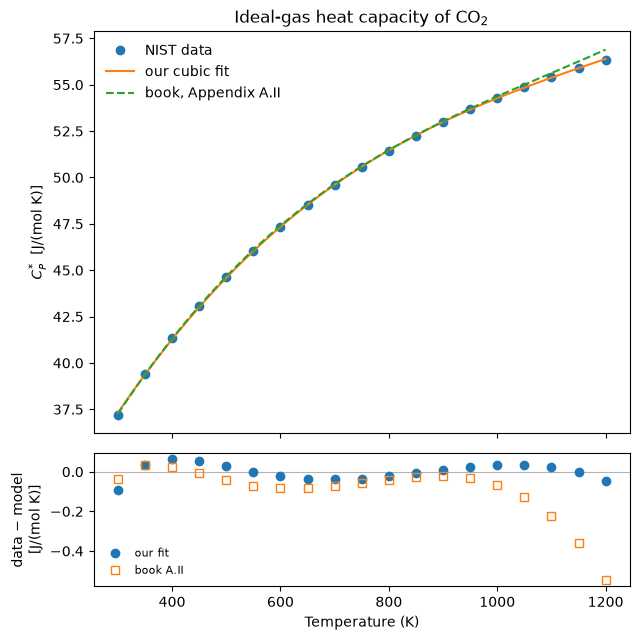

In [6]:
T_plot = np.linspace(300.0, 1200.0, 300)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(T_data, Cp_data, "o", label="NIST data")
ax1.plot(T_plot, cp_fit(T_plot), "-", label="our cubic fit")
ax1.plot(T_plot, cp_book(T_plot), "--", label="book, Appendix A.II")
ax1.set_ylabel(r"$C_P^{*}$  [J/(mol K)]")
ax1.set_title(r"Ideal-gas heat capacity of CO$_2$")
ax1.legend(frameon=False)

ax2.axhline(0.0, color="0.7", lw=0.8)
ax2.plot(T_data, Cp_data - cp_fit(T_data), "o", label="our fit")
ax2.plot(T_data, Cp_data - cp_book(T_data), "s", mfc="none", label="book A.II")
ax2.set_ylabel("data $-$ model\n[J/(mol K)]")
ax2.set_xlabel("Temperature (K)")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

Both residual patterns are **curves, not scatter**. That is the signature of a model that
is the wrong shape rather than of noisy data — a cubic cannot reproduce the Shomate
equation's $1/t^{2}$ term, so it misses in a systematic, sign-changing way. Random scatter
about zero would mean the model had captured everything and only measurement noise was
left. Always look at the residuals before believing a fit.

## 5. How can the coefficients disagree if the curves agree?

Because $1$, $T$, $T^{2}$ and $T^{3}$ do not point in independent directions over a
temperature range of only 300–1200 K. Over that interval $T^{2}$ and $T^{3}$ look rather
like each other, so an increase in $d$ can be canceled almost exactly by offsetting
changes in $a$, $b$ and $c$. **Many different coefficient sets produce nearly the same
curve.** The fit is well determined in what it *predicts* and badly determined in its
*parameters*.

Two consequences follow:

**Compare models by what you care about.** Compare predicted $C_P^{*}$, or the
$\Delta \underline{H} = \int C_P^{*}\,dT$ you actually want. Never coefficient by
coefficient — the comparison in §3 looks alarming and means almost nothing.

**Do not extrapolate.** The near-cancellation that keeps the curve tame holds *inside* the
fitted range. Outside it the terms no longer cancel and the highest power runs away. Every
row of Appendix A.II carries a temperature range for exactly this reason, and Chapter 3
returns to what it costs to ignore one.

In [7]:
T_far = np.array([1200.0, 2000.0, 3000.0])
print(f"{'T (K)':>7}{'our fit':>12}{'book A.II':>12}")
for Ti in T_far:
    print(f"{Ti:7.0f}{cp_fit(Ti):12.1f}{cp_book(Ti):12.1f}")
print("\nThe fitted range ended at 1200 K. Neither column past that is a heat capacity.")

  T (K)     our fit   book A.II
   1200        56.4        56.9
   2000        70.6        79.8
   3000       148.3       199.0

The fitted range ended at 1200 K. Neither column past that is a heat capacity.


## What this notebook shows

- **`np.polyfit` minimizes the squared misses**; it does not pass through the data. It
  returns coefficients **highest power first**.
- **A good fit can have badly determined coefficients.** Our cubic and the book's agree to
  a fraction of a J/(mol·K) while individual coefficients differ by tens of percent,
  because polynomial terms are nearly interchangeable over a narrow range.
- **Read the residuals, not the curve.** Both models miss *systematically*, in a smooth
  curve — the mark of a model of the wrong shape, not of noisy data.
- **A correlation is only a correlation inside its stated range.** Nothing in the arithmetic
  stops you evaluating the polynomial at 3000 K, and nothing in the output warns you.
- Read values out of a data file **by column name**, not by position.

**Where this goes next.** Two of the claims above — that a good fit can have badly determined
coefficients, and that extrapolation fails without warning — are asserted here and *measured*
in `ch3/Heat_capacity_from_molecular_structure.ipynb`. That notebook builds a heat capacity
from a molecule's structure instead of looking one up, so it knows the true answer exactly, and
can add noise on purpose to see what the noise costs. Come back to it after Chapter 3.

## Your turn

1. Pick a different gas from `pure_property.csv`, get its Shomate parameters from the NIST
   WebBook, and repeat §1–§4. Is the story the same?
2. Fit a **quadratic** and a **quartic** to the same CO$_2$ data (`np.polyfit(..., 2)` and
   `..., 4`). How do the RMSE and the residual pattern change? Is the quartic better in a
   way you would trust?
3. Fit the cubic to only the 300–600 K points, then plot it out to 1200 K alongside the
   full-range fit. This is the extrapolation warning in §5, done as an experiment.
4. Compute $\int_{300}^{1000} C_P^{*}\,dT$ from your coefficients and from the book's, and
   express the difference as a percentage. Which comparison — this one, or the
   coefficient table in §3 — tells you whether the two models actually disagree?